# Stable Diffusion

https://huggingface.co/stabilityai

https://github.com/huggingface/diffusers

**Stable Diffusion**은 텍스트(문장, 단어 등)를 입력하면 해당 내용을 바탕으로 이미지를 생성하는 **생성형 인공지능(Generative AI) 모델**이다.

2022년에 공개된 이 모델은 기존의 이미지 생성 AI와 달리 **Latent Diffusion Model(LDM)**이라는 구조를 사용한다.


- **텍스트-투-이미지(Text-to-Image) 기능**: 사용자가 입력한 텍스트 프롬프트(예: "노을지는 바다")를 해석해 그에 맞는 이미지를 만들어낸다.
- **잠재 공간(Latent Space) 활용**: 이미지를 바로 생성하지 않고, 먼저 이미지를 저차원의 잠재 공간(latent space)으로 압축하여 이 공간에서 노이즈를 추가하거나 제거하는 방식으로 이미지를 생성한다. 이 과정은 Variational Autoencoder(VAE)와 같은 기법을 활용한다.
- **확산(Diffusion) 기법**: 원래 이미지를 점진적으로 노이즈로 바꿨다가, 이 노이즈를 다시 거꾸로 제거해가며 이미지를 복원하는 과정을 학습한다. 실제 생성 시에는 완전한 노이즈 상태에서 시작해, 입력된 텍스트에 맞는 이미지를 점차적으로 만들어낸다.
- **메모리 효율성**: 잠재 공간에서 연산을 수행하기 때문에, 기존 모델보다 훨씬 적은 메모리와 연산 자원으로도 고해상도 이미지를 생성할 수 있다. 일반 데스크탑이나 노트북에서도 실행이 가능하다.
- **오픈소스**: 누구나 자유롭게 사용할 수 있으며, 커스터마이징 및 연구·서비스 개발이 가능하다.

**작동 원리:**

1. **학습 단계**  
   - 이미지와 그에 대한 설명(캡션) 쌍을 대량으로 학습한다.
   - 텍스트와 이미지의 특징을 잠재 공간에 매핑하는 방법을 익힌다.

2. **생성 단계**  
   - 사용자가 텍스트 프롬프트를 입력하면, 해당 텍스트의 의미를 잠재 공간에 반영한다.
   - 완전한 노이즈 상태에서 시작해, 여러 단계에 걸쳐 노이즈를 점차 제거하며 텍스트 의미에 맞는 이미지를 생성한다.
   - 마지막에 잠재 공간의 이미지를 실제 이미지로 복원한다.

이러한 구조 덕분에 Stable Diffusion은 **고품질 이미지 생성**, **빠른 처리 속도**, **낮은 하드웨어 요구사항**이라는 장점을 가진다.

수식적으로는, **확산 모델**은 다음과 같은 과정을 따른다.

- 순방향 과정:  

  $
  x_t = \sqrt{\alpha_t} x_{t-1} + \sqrt{1 - \alpha_t} \epsilon
  $

  여기서 $ x_t $는 t번째 단계의 이미지, $ \alpha_t $는 노이즈 스케줄, $ \epsilon $은 가우시안 노이즈이다.

- 역방향 과정(생성):

  $
  x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}} \epsilon_\theta(x_t, t) \right)
  $

  여기서 $ \epsilon_\theta $는 학습된 노이즈 예측 모델이다.

이 과정을 반복하면서 노이즈가 점점 줄고, 최종적으로 사람이 인식할 수 있는 이미지를 얻게 된다.

즉, **Stable Diffusion은 텍스트를 입력하면, 잠재 공간에서 노이즈를 점진적으로 제거하는 과정을 통해 고해상도 이미지를 효율적으로 생성하는 오픈소스 인공지능 모델**이다.

In [1]:
%pip install -Uq diffusers transformers accelerate safetensors 

Note: you may need to restart the kernel to use updated packages.


In [2]:

from diffusers import StableDiffusionPipeline
import torch

# MPS(Apple Silicon GPU) 사용 가능 여부 확인 및 디바이스 설정
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model_id = 'runwayml/stable-diffusion-v1-5'

# 사전학습 파이프라인 다운로드 및 로드
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,  # MPS에서도 메모리 절약을 위해 float16 사용 권장
    use_safetensors=True
).to(device)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /Users/jy/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /Users/jy/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Style Prompt

이미지 생성 프롬프트에서 `"digital art"` 대신 다양한 아트 스타일이나 기법을 지정할 수 있다. 이를 통해 같은 풍경이라도 전혀 다른 느낌의 이미지를 얻을 수 있다.

**대표적인 스타일 키워드**

- **photorealistic**  
  실제 사진처럼 사실적인 이미지를 생성한다.

- **oil painting**  
  유화 느낌의 질감과 붓터치가 강조된 이미지를 만든다.

- **watercolor**  
  수채화 특유의 번짐과 부드러운 색감이 표현된다.

- **pencil sketch**  
  연필로 그린 듯한 선과 음영이 강조된다.

- **anime style**  
  일본 애니메이션 특유의 캐릭터 스타일과 색감을 적용한다.

- **pixel art**  
  8비트 게임에서 볼 수 있는 도트 스타일 이미지를 생성한다.

- **cyberpunk**  
  미래적이고 네온빛이 강조된 사이버펑크 분위기를 낸다.

- **impressionist**  
  인상파 화풍(예: 모네, 르누아르)처럼 색점과 빛의 효과가 강조된다.

- **minimalist**  
  단순하고 깔끔한 형태와 색상으로 구성된 이미지를 만든다.

**예시 프롬프트 변형**

| 프롬프트 예시 |
|---|
| "A serene landscape of mountains during sunrise, photorealistic" |
| "A serene landscape of mountains during sunrise, oil painting" |
| "A serene landscape of mountains during sunrise, watercolor" |
| "A serene landscape of mountains during sunrise, pencil sketch" |
| "A serene landscape of mountains during sunrise, anime style" |
| "A serene landscape of mountains during sunrise, pixel art" |
| "A serene landscape of mountains during sunrise, cyberpunk" |
| "A serene landscape of mountains during sunrise, impressionist" |
| "A serene landscape of mountains during sunrise, minimalist" |

**참고 사항**

- 스타일 키워드는 영어로 입력하는 것이 일반적이다.
- 여러 스타일을 조합해서 사용할 수도 있다.  
  예: `"A serene landscape of mountains during sunrise, watercolor, minimalist"`
- 스타일에 따라 이미지의 분위기, 색감, 디테일이 크게 달라진다

In [3]:
# 재현 가능한 결과를 위한 Pytorch 난수 시드 고정 함수
def set_seed(seed: int):
    torch.manual_seed(seed)             # CPU 난수 시드 고정
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)    # GPU(CUDA) 난수 시드 고정
    if torch.mps.is_available():
        torch.mps.manual_seed(seed)         # GPU(MPS) 난수 시드 고정


  0%|          | 0/50 [00:00<?, ?it/s]

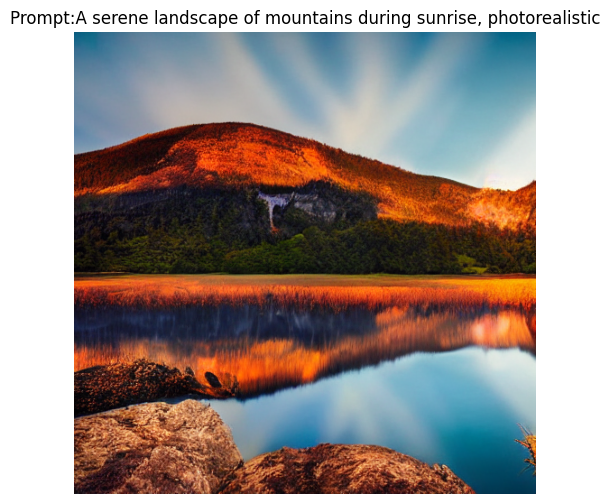

In [4]:
from PIL import Image               # 생성 결과 이미지 타입 힌트/처리용
import matplotlib.pyplot as plt     # 이미지 시각화용

prompt =  "A serene landscape of mountains during sunrise, photorealistic" 

set_seed(100)   # 난수 시드 고정(재현성)

result = pipe(
    prompt,
    num_inference_steps=50, # 샘플링 스탭 수 (높으면 품질은 증가하나 시간이 많이 듦)
    guidance_scale=7.5      # 프롬프트 반영 강도(높으면 프롬프트에 충실해지나 부자연스러울 가능성있음)
)
image: Image.Image = result.images[0]    # 첫 번째 이미지 꺼내오기(image 타입은 Image.Image)

plt.figure(figsize=(6,6))
plt.imshow(image)   # 이미지 표시
plt.axis("off")     # 축 숨김
plt.title("Prompt:" + prompt)
plt.show()


In [5]:
# 이미지 저장
image.save('photorealistic.png')


Token indices sequence length is longer than the specified maximum sequence length for this model (156 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', holding a glowing sapphire sword that emits faint magical particles . the lighting is dramatic and volumetric , with warm orange sunlight piercing through soft clouds , creating god rays and long shadows . ultra - detailed textures , hyper - realistic materials , 8 k resolution , sharp focus , depth of field , cinematic color grading , epic scale composition , wide - angle lens , masterpiece , highly detailed , unreal engine render style .']


  0%|          | 0/50 [00:00<?, ?it/s]

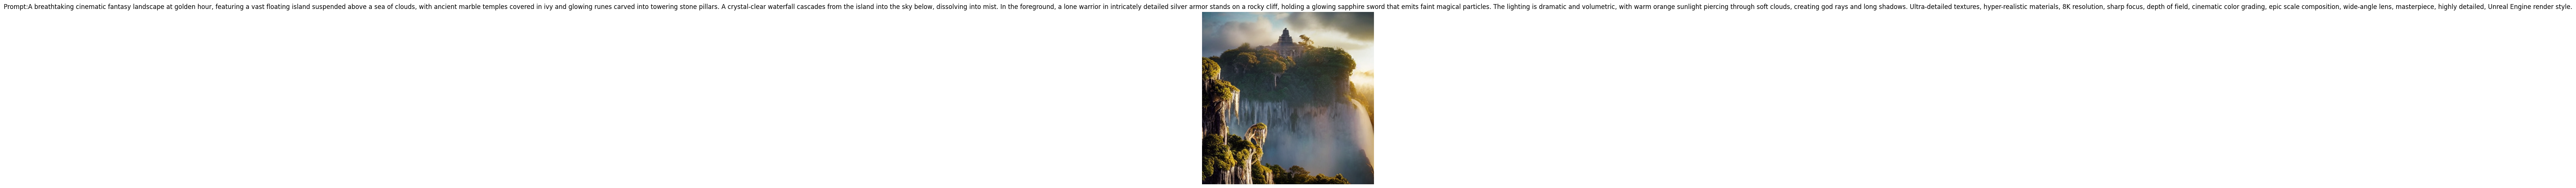

In [7]:
def generate_and_show(prompt: str):
    set_seed(100)   # 난수 시드 고정(재현성)

    result = pipe(
        prompt,
        num_inference_steps=50, # 샘플링 스탭 수 (높으면 품질은 증가하나 시간이 많이 듦)
        guidance_scale=7.5      # 프롬프트 반영 강도(높으면 프롬프트에 충실해지나 부자연스러울 가능성있음)
    )
    image: Image.Image = result.images[0]    # 첫 번째 이미지 꺼내오기(image 타입은 Image.Image)

    plt.figure(figsize=(6,6))
    plt.imshow(image)   # 이미지 표시
    plt.axis("off")     # 축 숨김
    plt.title("Prompt:" + prompt)
    plt.show()

generate_and_show( "A breathtaking cinematic fantasy landscape at golden hour, featuring a vast floating island suspended above a sea of clouds, with ancient marble temples covered in ivy and glowing runes carved into towering stone pillars. A crystal-clear waterfall cascades from the island into the sky below, dissolving into mist. In the foreground, a lone warrior in intricately detailed silver armor stands on a rocky cliff, holding a glowing sapphire sword that emits faint magical particles. The lighting is dramatic and volumetric, with warm orange sunlight piercing through soft clouds, creating god rays and long shadows. Ultra-detailed textures, hyper-realistic materials, 8K resolution, sharp focus, depth of field, cinematic color grading, epic scale composition, wide-angle lens, masterpiece, highly detailed, Unreal Engine render style.")

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['black tactical jacket with subtle led trims and transparent augmented - reality glasses projecting interface data . raindrops visible in mid - air , cinematic lighting , volumetric fog , shallow depth of field , ultra - detailed textures , photorealistic skin rendering , 8 5 mm lens , hdr , high contrast , 8 k resolution , extremely sharp , award - winning photography style .']


  0%|          | 0/50 [00:00<?, ?it/s]

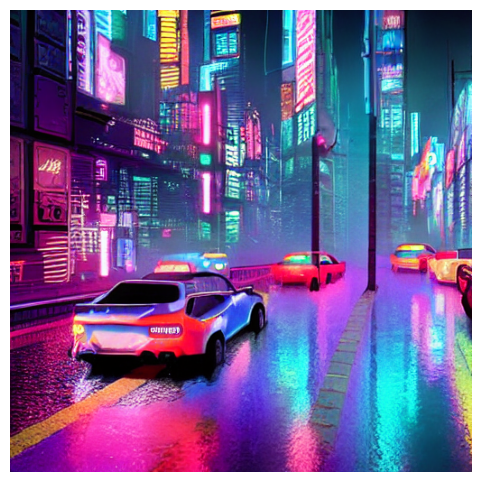

In [8]:
def generate_and_show(prompt: str):
    set_seed(100)   # 난수 시드 고정(재현성)

    result = pipe(
        prompt,
        num_inference_steps=50, # 샘플링 스탭 수 (높으면 품질은 증가하나 시간이 많이 듦)
        guidance_scale=7.5      # 프롬프트 반영 강도(높으면 프롬프트에 충실해지나 부자연스러울 가능성있음)
    )
    image: Image.Image = result.images[0]    # 첫 번째 이미지 꺼내오기(image 타입은 Image.Image)

    plt.figure(figsize=(6,6))
    plt.imshow(image)   # 이미지 표시
    plt.axis("off")     # 축 숨김
    plt.show()

generate_and_show("A hyper-realistic cyberpunk metropolis at night during heavy rain, neon holographic billboards reflecting off wet asphalt streets, towering skyscrapers covered with animated advertisements in multiple languages, glowing magenta and cyan lighting dominating the color palette. Steam rises from underground vents while autonomous vehicles glide silently above the streets. In the center stands a young woman with short silver hair, wearing a futuristic black tactical jacket with subtle LED trims and transparent augmented-reality glasses projecting interface data. Raindrops visible in mid-air, cinematic lighting, volumetric fog, shallow depth of field, ultra-detailed textures, photorealistic skin rendering, 85mm lens, HDR, high contrast, 8K resolution, extremely sharp, award-winning photography style.")